In [1]:
import numpy as np
from baryrat import aaa
from surmof_cavity import ag_surmof_cavity_trref as transmission
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial


In [2]:
np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])/300*2*np.pi

array([9.39945892, 9.17958854, 8.64853796])

In [3]:
wfreqr1 = 8.6485 - np.logspace(-5, -1, 25) 
wfreqr2 = 9.3995 - np.logspace(-5, -1, 25) 
wfreqr3 = 9.1796 - np.logspace(-5, -1, 25) 

wfreqi = np.linspace(-0.05, -0.07, 5)

wfreqr = np.concatenate([wfreqr1, wfreqr3, wfreqr2 ,np.linspace(5, 14, 20)])
wfreqr = np.sort(wfreqr)

wfreqi = np.concatenate([wfreqi, np.linspace(-1, 0.2, 20)])
wfreqi = np.sort(wfreqi)

Wfreqr, Wfreqi = np.meshgrid(wfreqr, wfreqi, indexing='ij')
Wfreq = Wfreqr + 1j*Wfreqi


In [4]:
all_poles = []
ts = 0.025*(np.arange(28)+1)
npoles = 3
for thickness in ts:
    f = partial(transmission, thickness=thickness, npoles=npoles)
    #r = brasil(f, [6, 12], 40)
    r = aaa(Wfreq, f, mmax=20)
    poles, residues = r.polres()
    all_poles.append(poles)

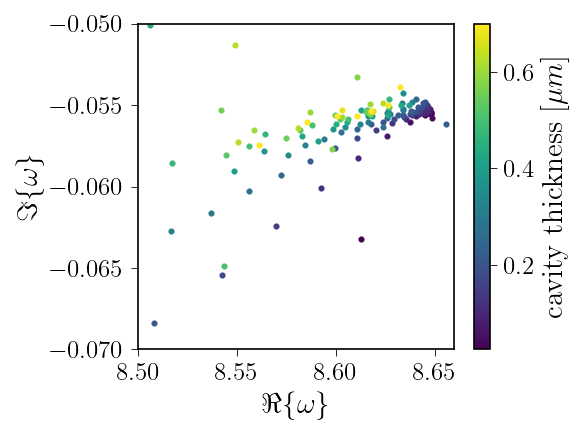

In [5]:
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(ts), vmax=max(ts))
colors = cmap(norm(ts))
for color, poles in zip(colors, all_poles):
    filtered_poles = poles[poles.imag<-0.01]
    plt.scatter(filtered_poles.real, filtered_poles.imag, color=color)

plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mu m$]")

plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")
plt.xlim(3, 16)
plt.ylim(-1, 0)
plt.savefig("pole_movement.png", dpi=600)

plt.xlim(8.5, 9.7)
plt.ylim(-0.1, -0.05)
plt.savefig("pole_movement_gap.png", dpi=600)

plt.xlim(8.5, 8.66)
plt.ylim(-0.07, -0.05)
plt.savefig("pole_movement_zoom.png", dpi=600)

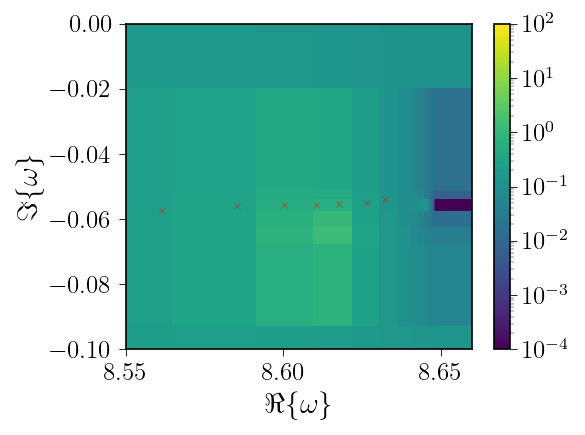

In [6]:
thickness = 0.025
Tr = transmission(Wfreq, thickness)

plt.pcolormesh(Wfreqr, Wfreqi, abs(Tr), norm="log", vmax=1e2, vmin=1e-4)
plt.colorbar()
plt.scatter(poles.real, poles.imag, marker="x", linewidths=0.2, color="red")
plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")
plt.xlim(8.55, 8.66)
plt.ylim(-0.1, 0)
plt.savefig("surmof_scan.png", dpi=900)

Text(0, 0.5, '$\\Im\\{\\omega\\}$')

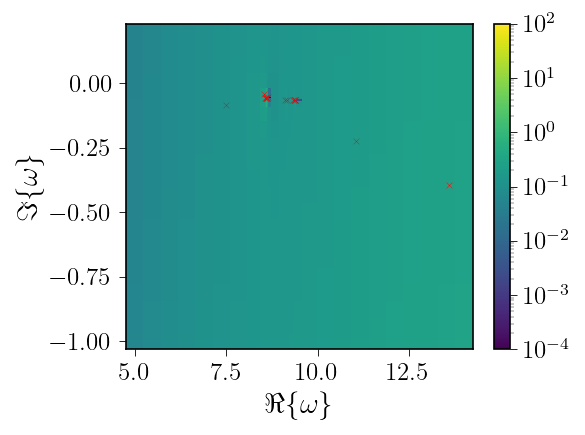

In [7]:
plt.pcolormesh(Wfreqr, Wfreqi, abs(Tr), norm="log", vmax=1e2, vmin=1e-4)
plt.colorbar()
plt.scatter(poles.real, poles.imag, marker="x", linewidths=0.2, color="red")
plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")